In [1]:
# ============================================================================
# Visualize Training Data
# ============================================================================
# This notebook loads and visualizes Hi-C contact matrices from the training
# dataset to verify data quality and understand the data distribution.
# ============================================================================

In [2]:
# %% Setup Python Path
import os
import sys

# Add parent directory to Python path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Added to Python path: {parent_dir}")

Added to Python path: /home1/smaruj/pytorch_akita


In [3]:
# %% Imports
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from data_preprocessing.dataset import HiCDataset
from utils import plot_contact_map, upper_triu_to_matrix

### Configuration

In [4]:
# Dataset to visualize
DATA_DIR = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC"
FOLD = "fold0"  # Which fold to visualize
NUM_EXAMPLES = 5  # Number of examples to plot
BATCH_SIZE = 2  # Batch size for loading data

# Matrix parameters
MATRIX_SIZE = 512  # Size of Hi-C contact matrix
DIAGONAL_OFFSET = 2  # Number of diagonals to skip

# Plotting parameters
VMIN = -0.6  # Minimum value for colormap
VMAX = 0.6  # Maximum value for colormap
COLORMAP = "RdBu_r"  # Seaborn color palette
FIGURE_SIZE = (5, 5)  # Figure size for each heatmap

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load Data

In [5]:
print("=" * 70)
print("Loading training data...")
print("=" * 70)
print(f"Data directory: {DATA_DIR}")
print(f"Fold: {FOLD}")
print()

# Get files for specified fold
all_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".pt")]
fold_files = [f for f in all_files if FOLD in f]

print(f"Found {len(fold_files)} files for {FOLD}")

# Create dataset and dataloader
dataset = HiCDataset(fold_files)
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

print(f"✓ Dataset created: {len(dataset)} samples")
print(f"✓ Dataloader created: {len(dataloader)} batches")
print()

Loading training data...
Data directory: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC
Fold: fold0

Found 8 files for fold0
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_0.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_1.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_2.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_3.pt
Loading file: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/Akita_pytorch_training_data/mouse_training_data/Hsieh2019_mESC/fold0_4.pt

### Load All Targets

In [6]:
print("Loading all contact matrices...")
all_targets = []

with torch.no_grad():
    for ohe_sequence, hic_vector in dataloader:
        ohe_sequence = ohe_sequence.to(device)
        hic_vector = hic_vector.to(device)
        all_targets.append(hic_vector.cpu())

# Concatenate all batches
all_targets = torch.cat(all_targets, axis=0)
print(f"✓ Loaded {len(all_targets)} contact matrices")
print(f"  Shape: {all_targets.shape}")
print()

Loading all contact matrices...
✓ Loaded 725 contact matrices
  Shape: torch.Size([725, 1, 130305])



### Data Statistics

In [7]:
# Compute statistics on the data
targets_flat = all_targets.flatten().numpy()
targets_flat_no_nan = targets_flat[~np.isnan(targets_flat)]

print(f"Total elements: {len(targets_flat):,}")
print(f"Non-NaN elements: {len(targets_flat_no_nan):,}")
print(
    f"NaN percentage: {(len(targets_flat) - len(targets_flat_no_nan)) / len(targets_flat) * 100:.2f}%"
)
print()
print("Value statistics (excluding NaN):")
print(f"  Min:    {targets_flat_no_nan.min():.4f}")
print(f"  Max:    {targets_flat_no_nan.max():.4f}")
print(f"  Mean:   {targets_flat_no_nan.mean():.4f}")
print(f"  Median: {np.median(targets_flat_no_nan):.4f}")
print(f"  Std:    {targets_flat_no_nan.std():.4f}")
print()

Total elements: 94,471,125
Non-NaN elements: 94,471,125
NaN percentage: 0.00%

Value statistics (excluding NaN):
  Min:    -3.7252
  Max:    3.2950
  Mean:   -0.1457
  Median: -0.1121
  Std:    0.4508



### Distribution Plot

Plotting value distribution...


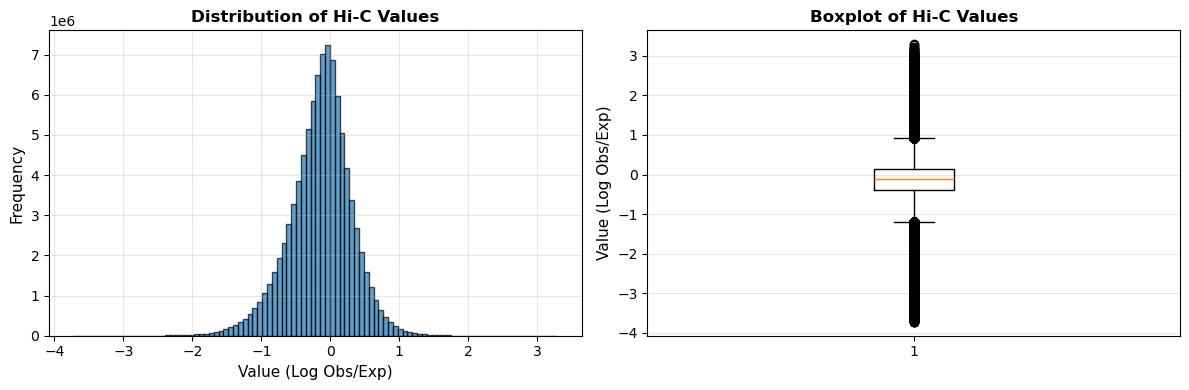

In [8]:
print("Plotting value distribution...")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(targets_flat_no_nan, bins=100, alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Value (Log Obs/Exp)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title("Distribution of Hi-C Values", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(targets_flat_no_nan, vert=True)
axes[1].set_ylabel("Value (Log Obs/Exp)", fontsize=11)
axes[1].set_title("Boxplot of Hi-C Values", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Visualize Example Contact Matrices

Visualizing 5 example contact matrices...

Example 1/5
----------------------------------------
  Min: -2.1645, Max: 2.0245, Mean: -0.1933

Example 2/5
----------------------------------------
  Min: -2.1307, Max: 1.6166, Mean: -0.2249

Example 3/5
----------------------------------------
  Min: -2.4404, Max: 2.0256, Mean: -0.1326

Example 4/5
----------------------------------------
  Min: -2.3230, Max: 2.3126, Mean: -0.1629

Example 5/5
----------------------------------------
  Min: -2.7138, Max: 2.3029, Mean: -0.2006

Visualization complete!


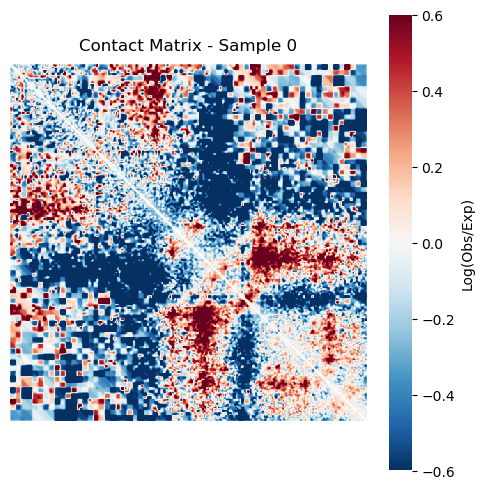

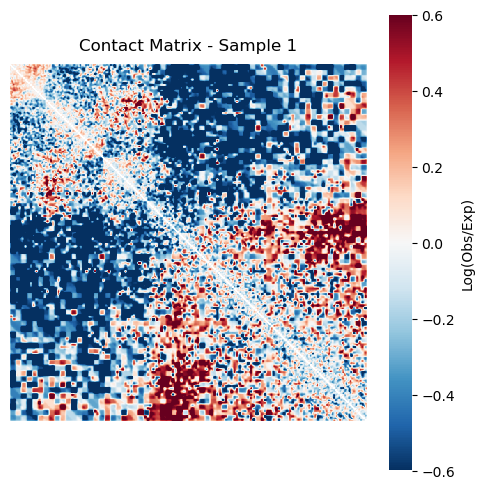

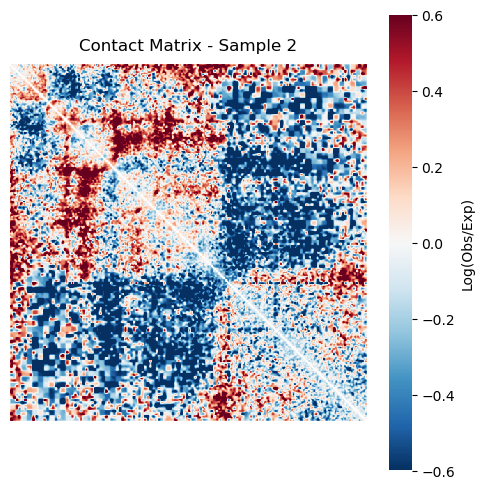

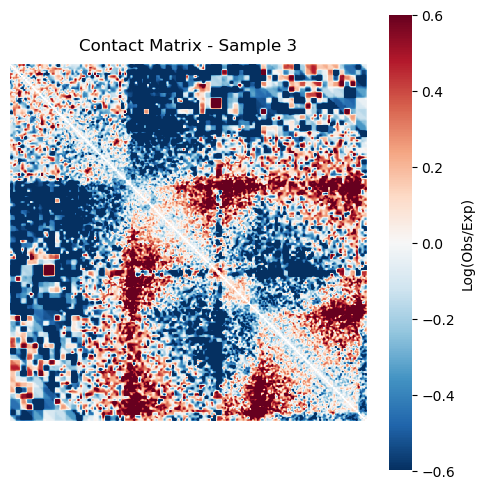

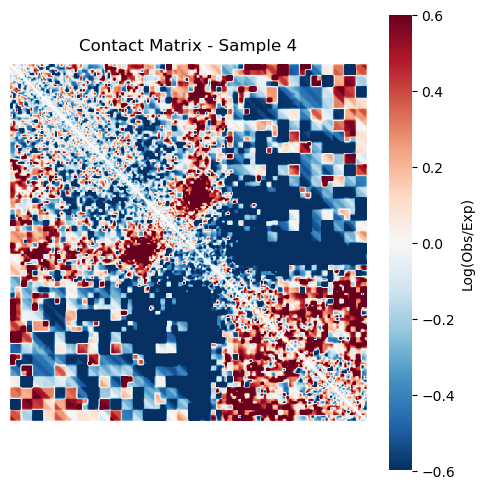

In [9]:
print("=" * 70)
print(f"Visualizing {NUM_EXAMPLES} example contact matrices...")
print("=" * 70)
print()

for idx in range(min(NUM_EXAMPLES, len(all_targets))):
    print(f"Example {idx + 1}/{NUM_EXAMPLES}")
    print("-" * 40)

    # Convert to matrix
    true_vec = all_targets[idx].reshape(-1)
    true_map = upper_triu_to_matrix(true_vec, matrix_len=MATRIX_SIZE, num_diags=DIAGONAL_OFFSET)

    # Compute statistics for this matrix
    matrix_flat = true_map.flatten()
    matrix_flat_no_nan = matrix_flat[~np.isnan(matrix_flat)]

    print(
        f"  Min: {matrix_flat_no_nan.min():.4f}, "
        f"Max: {matrix_flat_no_nan.max():.4f}, "
        f"Mean: {matrix_flat_no_nan.mean():.4f}"
    )

    # Plot
    plot_contact_map(true_map, title=f"Contact Matrix - Sample {idx}")
    print()

print("=" * 70)
print("Visualization complete!")
print("=" * 70)